<a href="https://colab.research.google.com/github/grabuffo/BrainStim_ANN_fMRI_HCP/blob/main/notebooks/Fit_TMS_fMRI_stimulation_persubject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/grabuffo/BrainStim_ANN_fMRI_HCP/blob/main/notebooks/Fit_TMS_fMRI_stimulation_persubject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Per-Subject ANN Models on TMS-fMRI Stimulation Sessions

**Approach:** Fit individual ANN models for each subject on TMS stimulation data, with explicit modeling of stimulation as a perturbation input.

This notebook implements a new strategy for modeling brain dynamics under stimulation:
- Train separate models *per subject* (not population-level)
- Use *stimulation sessions* as training data (not just resting-state)
- Explicitly include *stimulation timing and target region* in the model
- Evaluate predictions against empirical fMRI responses to TMS pulses

This approach aims to better capture subject-specific dynamics and reproduce realistic stimulation effects.

## Section 1: Setup and Data Loading

Mount Google Drive, clone the GitHub repository, define paths for TMS-fMRI data and stimulation session files, and import required libraries.

In [1]:
# --- Setup cell ---

# 1️⃣ Mount Google Drive (for data)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 2️⃣ Clone GitHub repository (for code)
import os, sys, subprocess

repo_dir = "/content/BrainStim_ANN_fMRI_HCP"
if not os.path.exists(repo_dir):
    !git clone https://github.com/grabuffo/BrainStim_ANN_fMRI_HCP.git
else:
    print("Repo already exists ✅")

# 3️⃣ Define paths (TMS-fMRI with stimulation sessions)
base_dir = "/content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data"
data_dir = os.path.join(base_dir, "TMS_fMRI")
preproc_dir = os.path.join(base_dir, "preprocessed_subjects_tms_fmri")
dataset_pkl = os.path.join(data_dir, "dataset_tian50_schaefer400_allruns.pkl")

# Where to save per-subject models
weights_dir = os.path.join(preproc_dir, "trained_models_MLP_tms_fmri_persubject")
results_dir = os.path.join(preproc_dir, "results_tms_fmri_persubject")
os.makedirs(weights_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

# 4️⃣ Add repo to import path + core imports
sys.path.append(repo_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pickle
import json
from scipy import stats
from src import NPI
from src.preprocessing_tms_fmri import preprocess_run, make_inputs_targets

import gc
import warnings
warnings.filterwarnings('ignore')

# 5️⃣ Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Running on:", torch.cuda.get_device_name(0))
else:
    print("⚠️  GPU not detected — training will run on CPU.")

print(f"\nDataset path: {dataset_pkl}")

Mounted at /content/drive
Cloning into 'BrainStim_ANN_fMRI_HCP'...
remote: Enumerating objects: 682, done.
remote: Counting objects: 100% (144/144), done.
remote: Compressing objects: 100% (127/127), done.
remote: Total 682 (delta 69), reused 14 (delta 14), pack-reused 538 (from 1)
Receiving objects: 100% (682/682), 88.46 MiB | 1.64 MiB/s, done.
Resolving deltas: 100% (246/246), done.
PyTorch version: 2.10.0+cu128
CUDA available: True
Running on: Tesla T4

Dataset path: /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/TMS_fMRI/dataset_tian50_schaefer400_allruns.pkl


In [2]:
# --- Configuration and Hyperparameters ---

# Data parameters
ROI_num = 450                   # Tian 50 + Schaefer 400
using_steps = 3                 # S: number of past steps for prediction
tr_stim = 2.4                   # Repetition time (seconds)

# Preprocessing
remove_initial_trs = 30         # Drop first N timepoints per session
low_hz, high_hz = 0.008, 0.08  # Bandpass filter range
test_fraction = 0.5             # Per-session split (last 50% as test)

# Model architecture
hidden_dim = 256                # First hidden layer size
latent_dim = 128                # Second hidden layer (bottleneck)

# Training
batch_size = 32
num_epochs = 100
learning_rate = 2.5e-4
l2_reg = 5e-5

print("Configuration:")
print(f"  ROIs: {ROI_num}")
print(f"  Temporal window: {using_steps} steps × {tr_stim}s = {using_steps * tr_stim:.1f}s")
print(f"  Input dimension: ({using_steps * ROI_num}) + {ROI_num} = {using_steps * ROI_num + ROI_num}")
print(f"  Output dimension: {ROI_num}")
print(f"  Preprocessing: drop {remove_initial_trs} TRs, BP [{low_hz}, {high_hz}] Hz")
print(f"  Training: {num_epochs} epochs, batch={batch_size}, lr={learning_rate}, l2={l2_reg}")

Configuration:
  ROIs: 450
  Temporal window: 3 steps × 2.4s = 7.2s
  Input dimension: (1350) + 450 = 1800
  Output dimension: 450
  Preprocessing: drop 30 TRs, BP [0.008, 0.08] Hz
  Training: 100 epochs, batch=32, lr=0.00025, l2=5e-05


## Section 2: Extract Stimulation Sessions and Metadata

Load stimulation session time series and metadata (stimulated region, stimulation timing/onset).

In [3]:
# --- Load main dataset with stimulation sessions ---

with open(dataset_pkl, "rb") as f:
    dataset_emp = pickle.load(f)

print(f"✅ Loaded dataset with {len(dataset_emp)} subjects")

# Quick inspection: examine one subject's structure
sample_sub = next(iter(dataset_emp.keys()))
print(f"\nSample subject: {sample_sub}")
print(f"Available tasks: {list(dataset_emp[sample_sub].keys())}")

# Check if task-stim (stimulation) data exists
if 'task-stim' in dataset_emp[sample_sub]:
    print(f"✅ Has 'task-stim' stimulation sessions: {len(dataset_emp[sample_sub]['task-stim'])} sessions")
    sample_stim = dataset_emp[sample_sub]['task-stim'][0]
    print(f"   Sample session keys: {list(sample_stim.keys())}")
    if 'target' in sample_stim:
        print(f"   Target region shape: {sample_stim['target'].shape}")
    if 'stim time' in sample_stim:
        stim_df = sample_stim['stim time']
        print(f"   Stim time DataFrame shape: {stim_df.shape}")
        print(f"   Stim time columns: {list(stim_df.columns)}")
        print(f"   First few rows:\n{stim_df.head()}")
else:
    print("❌ No 'task-stim' data found!")

✅ Loaded dataset with 46 subjects

Sample subject: sub-NTHC1001
Available tasks: ['task-rest', 'task-stim']
✅ Has 'task-stim' stimulation sessions: 1 sessions
   Sample session keys: ['time series', 'metadata', 'target', 'stim time']
   Target region shape: (450,)
   Stim time DataFrame shape: (68, 3)
   Stim time columns: ['onset', 'duration', 'trial_type']
   First few rows:
   onset  duration trial_type
0   11.8       0.3       stim
1   14.2       0.3       stim
2   28.6       0.3       stim
3   35.8       0.3       stim
4   43.0       0.3       stim


## Section 3: Prepare Per-Subject Training Data

For each subject, extract inputs and targets from stimulation sessions using the perturbation framework.

**IMPORTANT QUESTIONS FOR USER:**  
Before proceeding, I need clarification on the data preparation strategy:

1. **Training target and duration:** Should we use the *entire stimulation session* as one concatenated time series for training, or only *post-stimulus windows* aligned to each pulse?

2. **Perturbation vector encoding:** How should we encode "which region was stimulated"? Options:
   - Concatenate a (450,) binary target vector (1 for stimulated region, 0 elsewhere) with each time step?
   - Use the on/off state of stimulation (binary scalar)?
   - Include stimulus timing explicitly (time since last pulse)?

3. **Multiple sessions per subject:** Different stimulation sessions target different regions. Should we:
   - Train a *single model per subject* on data from *all stimulation sessions* (mixed targets)?
   - Train *separate models per (subject, stimulation target)* pair?

4. **Input encoding:** Should the perturbation be at the model input level (concatenated to state), or supervised as an external channel during training?

For now, I'll create a **template structure** that you can customize. Please answer the above questions, and I'll implement the specific logic.

In [4]:
# --- Prepare per-subject training data from stimulation sessions ---
# Strategy:
#   1. For each subject, extract ALL stimulation sessions (task-stim)
#   2. For each session, preprocess the time series
#   3. Build training input with TWO components:
#      a) Brain state: (S, N) = S past timesteps × N regions (flattened: S*N)
#      b) Target region: (N,) = binary one-hot vector of stimulated region
#   4. Use entire session with per-session train/test split
#   5. One ANN model trained per subject (learns dynamics across different targets)
#   6. KEEP TRAIN AND TEST DATA SEPARATE for validation during training

print("="*70)
print("PREPARING PER-SUBJECT TRAINING DATA FROM STIMULATION SESSIONS")
print("="*70)

# Configuration
remove_initial_trs = 30
low_hz, high_hz = 0.008, 0.08
tr_stim = 2.4
test_fraction = 0.3  # per session
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Subject IDs and data collection
subject_ids = sorted([k for k in dataset_emp.keys()])
print(f"\nFound {len(subject_ids)} subjects")

# Dictionary to store per-subject training data (will be filled per subject)
per_subject_data = {}

# --- Iterate over subjects and collect stimulation sessions ---
for sub_id in subject_ids:
    if 'task-stim' not in dataset_emp[sub_id]:
        print(f"⚠️  {sub_id}: no task-stim data, skipping")
        continue

    stim_sessions = dataset_emp[sub_id]['task-stim']
    print(f"\n{sub_id}: {len(stim_sessions)} stimulation sessions")

    sub_train_inputs = []
    sub_train_targets = []
    sub_test_inputs = []
    sub_test_targets = []

    # --- Process each stimulation session ---
    for sess_idx in sorted(stim_sessions.keys()):
        sess_data = stim_sessions[sess_idx]

        # Extract signal and metadata
        ts = sess_data.get('time series')
        if ts is None or len(ts) == 0:
            print(f"  Session {sess_idx}: empty, skip")
            continue

        metadata = sess_data.get('metadata', {})
        target_vec = sess_data.get('target')  # (N,) binary vector
        stim_time_df = sess_data.get('stim time')  # DataFrame with onset/duration

        # Validate target
        if target_vec is None:
            print(f"  Session {sess_idx}: no target vector, skip")
            continue

        target_vec = np.asarray(target_vec, dtype=np.float32).ravel()
        if target_vec.shape[0] != ROI_num:
            print(f"  Session {sess_idx}: target shape {target_vec.shape} != {ROI_num}, skip")
            continue

        # Preprocess: drop initial points, bandpass filter, z-score
        ts = np.asarray(ts, dtype=np.float32)
        if ts.shape[0] <= remove_initial_trs:
            print(f"  Session {sess_idx}: too short after trimming, skip")
            continue

        ts_drop = ts[remove_initial_trs:, :]
        ts_proc = preprocess_run(
            ts_drop,
            tr=tr_stim,
            n_drop=0,  # already dropped
            low=low_hz,
            high=high_hz,
            order=2,
            zscore=True
        )

        if ts_proc.shape[0] <= using_steps:
            print(f"  Session {sess_idx}: processed too short, skip")
            continue

        # Split per-session train/test (preserve temporal structure)
        n_train = int((1.0 - test_fraction) * ts_proc.shape[0])
        ts_train = ts_proc[:n_train]
        ts_test = ts_proc[n_train:]

        # Extract stimulus timing from 'stim time' DataFrame
        stim_pulse = np.zeros(ts_proc.shape[0], dtype=np.float32)
        if stim_time_df is not None and len(stim_time_df) > 0:
            # Get onset times (in seconds) and convert to TR indices in the RAW time series
            stim_onsets = stim_time_df['onset'].values
            raw_tr_indices = np.round(stim_onsets / tr_stim).astype(int)

            # Filter to TRs that remain after dropping first 30
            valid_raw_indices = raw_tr_indices[raw_tr_indices >= remove_initial_trs]

            # Convert to indices in preprocessed time series (account for dropped TRs)
            preprocessed_indices = valid_raw_indices - remove_initial_trs

            # Mark stimulus pulses in preprocessed time series
            valid_preprocessed_indices = preprocessed_indices[preprocessed_indices < ts_proc.shape[0]]
            stim_pulse[valid_preprocessed_indices] = 1.0

        # Build inputs/targets with stimulus information and timing
        def make_inputs_targets_with_stim(signals, steps, stim_target_vec, stim_timing):
            """
            Build sliding-window inputs with stimulus channel and timing.

            Args:
                signals: (T, N) time series
                steps: S (window length)
                stim_target_vec: (N,) binary target vector
                stim_timing: (T,) binary stimulus pulse timings

            Returns:
                inputs: (T-S, S*N + N + 1) = [brain_state | target | stim_pulse]
                targets: (T-S, N)
            """
            X = np.asarray(signals, dtype=np.float32)
            T, N = X.shape

            inputs = np.empty((T - steps, steps * N + N + 1), dtype=np.float32)
            for t in range(T - steps):
                brain_state = X[t : t + steps].reshape(-1)
                inputs[t] = np.concatenate([brain_state, stim_target_vec, [stim_timing[t]]])

            targets = X[steps:, :]
            return inputs, targets

        X_train, Y_train = make_inputs_targets_with_stim(ts_train, using_steps, target_vec, stim_pulse[:n_train])
        X_test, Y_test = make_inputs_targets_with_stim(ts_test, using_steps, target_vec, stim_pulse[n_train:])

        if X_train.shape[0] > 0:
            sub_train_inputs.append(X_train)
            sub_train_targets.append(Y_train)

        if X_test.shape[0] > 0:
            sub_test_inputs.append(X_test)
            sub_test_targets.append(Y_test)

        print(f"  Session {sess_idx}: train {X_train.shape[0]} + test {X_test.shape[0]} samples")

    if sub_train_inputs:
        X_train_all = np.concatenate(sub_train_inputs, axis=0)
        Y_train_all = np.concatenate(sub_train_targets, axis=0)
        X_test_all = np.concatenate(sub_test_inputs, axis=0) if sub_test_inputs else np.empty((0, X_train_all.shape[1]), dtype=np.float32)
        Y_test_all = np.concatenate(sub_test_targets, axis=0) if sub_test_targets else np.empty((0, Y_train_all.shape[1]), dtype=np.float32)

        per_subject_data[sub_id] = {
            'X_train': X_train_all,
            'Y_train': Y_train_all,
            'X_test': X_test_all,
            'Y_test': Y_test_all,
            'n_train_samples': X_train_all.shape[0],
            'n_test_samples': X_test_all.shape[0],
        }
        print(f"✓ {sub_id}: train {X_train_all.shape[0]} + test {X_test_all.shape[0]} samples")
    else:
        print(f"✗ {sub_id}: no valid sessions")

print("\n" + "="*70)
print(f"Data prepared for {len(per_subject_data)} subjects")
print("="*70)


PREPARING PER-SUBJECT TRAINING DATA FROM STIMULATION SESSIONS

Found 46 subjects

sub-NTHC1001: 1 stimulation sessions
  Session 0: train 92 + test 39 samples
✓ sub-NTHC1001: train 92 + test 39 samples

sub-NTHC1003: 1 stimulation sessions
  Session 0: train 92 + test 39 samples
✓ sub-NTHC1003: train 92 + test 39 samples

sub-NTHC1009: 6 stimulation sessions
  Session 0: train 92 + test 39 samples
  Session 1: train 92 + test 39 samples
  Session 2: train 92 + test 39 samples
  Session 3: train 92 + test 39 samples
  Session 4: train 92 + test 39 samples
  Session 5: train 92 + test 39 samples
✓ sub-NTHC1009: train 552 + test 234 samples

sub-NTHC1015: 18 stimulation sessions
  Session 0: train 92 + test 39 samples
  Session 1: train 92 + test 39 samples
  Session 2: train 92 + test 39 samples
  Session 3: train 92 + test 39 samples
  Session 4: train 92 + test 39 samples
  Session 5: train 92 + test 39 samples
  Session 6: train 92 + test 39 samples
  Session 7: train 92 + test 39 sam

## Section 4: Build and Train Per-Subject Perturbation Models

For each subject independently, instantiate and train an ANN with explicit stimulation input channels.

In [5]:
# --- Build and train per-subject models with stimulus input ---

import torch.nn as nn
import torch.optim as optim

print("="*70)
print("TRAINING PER-SUBJECT MODELS WITH STIMULUS INPUT")
print("="*70)

# Hyperparameters
batch_size = 32
num_epochs = 100
learning_rate = 2.5e-4
l2_reg = 5e-5

class ANN_MLP_with_Stimulus(nn.Module):
    """
    MLP with stimulus input channel and timing.

    Input: Concatenation of:
      - Brain state: (B, S*N) = S past steps × N regions
      - Stimulus target: (B, N) = one-hot binary target region
      - Stimulus timing: (B, 1) = binary pulse indicator (0 or 1)
    Total input dimension: S*N + N + 1

    Output: (B, N) next-step brain state
    """
    def __init__(self, roi_num, using_steps, hidden_dim=256, latent_dim=128):
        super().__init__()
        brain_dim = using_steps * roi_num
        stim_dim = roi_num  # target vector
        stim_timing_dim = 1  # binary pulse indicator
        input_dim = brain_dim + stim_dim + stim_timing_dim
        output_dim = roi_num

        self.func = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU(),
            nn.Linear(latent_dim, output_dim),
        )

    def forward(self, x):
        """x: (B, S*N + N)"""
        return self.func(x)

def train_subject_model(
    model,
    X_train, Y_train,
    X_test=None, Y_test=None,
    batch_size=32,
    num_epochs=100,
    lr=2.5e-4,
    l2=5e-5,
    device=device,
):
    """
    Train a model on per-subject data with validation on test set.

    Args:
        model: ANN model
        X_train: (M, S*N + N) training inputs
        Y_train: (M, N) training targets
        X_test: (K, S*N + N) test inputs (optional)
        Y_test: (K, N) test targets (optional)
        ...

    Returns:
        model: trained model
        train_losses: list of training losses per epoch
        test_losses: list of test losses per epoch (if provided)
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=l2)
    loss_fn = nn.MSELoss()

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32, device=device)
    Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32, device=device)

    X_test_tensor = None
    Y_test_tensor = None
    if X_test is not None and X_test.shape[0] > 0:
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)
        Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32, device=device)

    n_samples = X_train_tensor.shape[0]
    train_losses = []
    test_losses = []

    for epoch in range(num_epochs):
        model.train()

        # Shuffle
        perm = torch.randperm(n_samples, device=device)
        epoch_loss = 0.0
        n_batches = 0

        for i in range(0, n_samples, batch_size):
            idx = perm[i:i+batch_size]
            X_batch = X_train_tensor[idx]
            Y_batch = Y_train_tensor[idx]

            # Forward
            Y_pred = model(X_batch)
            loss = loss_fn(Y_pred, Y_batch)

            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_train_loss = epoch_loss / max(1, n_batches)
        train_losses.append(avg_train_loss)

        # Evaluate on test set if provided
        if X_test_tensor is not None:
            model.eval()
            with torch.no_grad():
                Y_test_pred = model(X_test_tensor)
                test_loss = loss_fn(Y_test_pred, Y_test_tensor).item()
            test_losses.append(test_loss)

            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f"  Epoch {epoch+1:3d}/{num_epochs} | train loss: {avg_train_loss:.6f} | test loss: {test_loss:.6f}")
        else:
            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f"  Epoch {epoch+1:3d}/{num_epochs} | train loss: {avg_train_loss:.6f}")

    return model, train_losses, test_losses

# --- Train models per subject ---
trained_models = {}
training_results = {}

for sub_id in sorted(per_subject_data.keys()):
    print(f"\n--- {sub_id} ---")

    data = per_subject_data[sub_id]
    X_train = data['X_train']
    Y_train = data['Y_train']
    X_test = data['X_test']
    Y_test = data['Y_test']

    # Filter: skip subjects with insufficient training data
    min_train_samples = 600
    n_train_samples = X_train.shape[0]
    if n_train_samples < min_train_samples:
        print(f"⚠️  Skipping: insufficient training data ({n_train_samples} < {min_train_samples})")
        continue

    print(f"Training shape: {X_train.shape}, Test shape: {X_test.shape}")

    # Build model
    model = ANN_MLP_with_Stimulus(roi_num=ROI_num, using_steps=using_steps)

    # Train (with test data for validation)
    model, train_losses, test_losses = train_subject_model(
        model, X_train, Y_train,
        X_test=X_test, Y_test=Y_test,
        batch_size=batch_size,
        num_epochs=num_epochs,
        lr=learning_rate,
        l2=l2_reg,
        device=device,
    )

    # Save
    trained_models[sub_id] = model
    training_results[sub_id] = {
        'train_loss': train_losses,
        'test_loss': test_losses,
        'final_train_loss': float(train_losses[-1]),
        'final_test_loss': float(test_losses[-1]) if test_losses else None,
        'n_train_samples': int(X_train.shape[0]),
        'n_test_samples': int(X_test.shape[0]),
        'input_dim': int(X_train.shape[1]),
        'output_dim': int(Y_train.shape[1]),
    }

    print(f"✓ Final train loss: {train_losses[-1]:.6f}")
    if test_losses:
        print(f"✓ Final test loss: {test_losses[-1]:.6f}")

print("\n" + "="*70)
print(f"✓ Trained {len(trained_models)} per-subject models")
print("="*70)


TRAINING PER-SUBJECT MODELS WITH STIMULUS INPUT

--- sub-NTHC1001 ---
⚠️  Skipping: insufficient training data (92 < 600)

--- sub-NTHC1003 ---
⚠️  Skipping: insufficient training data (92 < 600)

--- sub-NTHC1009 ---
⚠️  Skipping: insufficient training data (552 < 600)

--- sub-NTHC1015 ---
Training shape: (1656, 1801), Test shape: (702, 1801)
  Epoch   1/100 | train loss: 0.737840 | test loss: 0.659594
  Epoch  10/100 | train loss: 0.182972 | test loss: 0.369351
  Epoch  20/100 | train loss: 0.118957 | test loss: 0.338861
  Epoch  30/100 | train loss: 0.090198 | test loss: 0.331666
  Epoch  40/100 | train loss: 0.073079 | test loss: 0.328115
  Epoch  50/100 | train loss: 0.061754 | test loss: 0.325917
  Epoch  60/100 | train loss: 0.054075 | test loss: 0.326262
  Epoch  70/100 | train loss: 0.049157 | test loss: 0.328150
  Epoch  80/100 | train loss: 0.047984 | test loss: 0.329163
  Epoch  90/100 | train loss: 0.040339 | test loss: 0.325966
  Epoch 100/100 | train loss: 0.038180 | te

In [6]:
# --- Save trained models and results ---

import json

print("Saving models and results...")

# Save each subject's model
for sub_id, model in trained_models.items():
    model_path = os.path.join(weights_dir, f"{sub_id}_MLP_with_stim.pt")
    torch.save(model.state_dict(), model_path)
    print(f"  Saved: {model_path}")

# Save training results summary
results_summary = {
    'method': 'MLP_with_stimulus',
    'roi_num': ROI_num,
    'using_steps': using_steps,
    'batch_size': batch_size,
    'num_epochs': num_epochs,
    'learning_rate': learning_rate,
    'l2_reg': l2_reg,
    'input_dim_per_sample': (using_steps * ROI_num) + ROI_num,  # brain_state + stimulus
    'output_dim': ROI_num,
    'subjects': training_results,
}

results_path = os.path.join(results_dir, "training_results_persubject.json")
with open(results_path, 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f"\n✓ Results saved: {results_path}")
print(f"\n{len(trained_models)} models trained successfully")

Saving models and results...
  Saved: /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/trained_models_MLP_tms_fmri_persubject/sub-NTHC1015_MLP_with_stim.pt
  Saved: /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/trained_models_MLP_tms_fmri_persubject/sub-NTHC1016_MLP_with_stim.pt
  Saved: /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/trained_models_MLP_tms_fmri_persubject/sub-NTHC1019_MLP_with_stim.pt
  Saved: /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/trained_models_MLP_tms_fmri_persubject/sub-NTHC1021_MLP_with_stim.pt
  Saved: /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/trained_models_MLP_tms_fmri_persubject/sub-NTHC1022_MLP_with_stim.pt
  Saved: /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/trained_models_MLP_tms_fmri_pers

## Section 5: Evaluate Model Predictions Against Empirical Responses

For each subject, compare model predictions of brain responses to empirical fMRI responses following stimulation.

In [8]:
# --- Evaluate per-subject models ON BOTH TRAIN AND TEST DATA ---

print("="*70)
print("EVALUATING PER-SUBJECT MODELS ON TRAIN AND TEST DATA")
print("="*70)

# Compute metrics on both training and test portions
evaluation_results = {}

for sub_id in sorted(trained_models.keys()):
    print(f"\n{sub_id}:")

    model = trained_models[sub_id]
    model.eval()

    if 'task-stim' not in dataset_emp[sub_id]:
        print("  No task-stim data")
        continue

    stim_sessions = dataset_emp[sub_id]['task-stim']
    sub_session_metrics = {}

    # --- Evaluate on each session (both train and test) ---
    for sess_idx in sorted(stim_sessions.keys()):
        sess_data = stim_sessions[sess_idx]

        ts = sess_data.get('time series')
        target_vec = sess_data.get('target')
        stim_time_df = sess_data.get('stim time')  # Get stimulus timing

        if ts is None or target_vec is None:
            continue

        # Preprocess
        ts = np.asarray(ts, dtype=np.float32)
        if ts.shape[0] <= remove_initial_trs:
            continue

        ts_drop = ts[remove_initial_trs:, :]
        ts_proc = preprocess_run(ts_drop, tr=tr_stim, n_drop=0, low=low_hz, high=high_hz, order=2, zscore=True)

        if ts_proc.shape[0] <= using_steps:
            continue

        target_vec = np.asarray(target_vec, dtype=np.float32).ravel()

        # Extract stimulus timing (same as in data preparation)
        stim_pulse = np.zeros(ts_proc.shape[0], dtype=np.float32)
        if stim_time_df is not None and len(stim_time_df) > 0:
            stim_onsets = stim_time_df['onset'].values
            raw_tr_indices = np.round(stim_onsets / tr_stim).astype(int)
            valid_raw_indices = raw_tr_indices[raw_tr_indices >= remove_initial_trs]
            preprocessed_indices = valid_raw_indices - remove_initial_trs
            valid_preprocessed_indices = preprocessed_indices[preprocessed_indices < ts_proc.shape[0]]
            stim_pulse[valid_preprocessed_indices] = 1.0

        # Split into train/test (respecting the same split as training)
        n_train = int((1.0 - test_fraction) * ts_proc.shape[0])
        ts_train_only = ts_proc[:n_train]
        ts_test_only = ts_proc[n_train:]
        stim_train_only = stim_pulse[:n_train]
        stim_test_only = stim_pulse[n_train:]

        session_metrics = {'train': {}, 'test': {}}

        # Evaluate on both portions
        for split_name, ts_split, stim_split in [('train', ts_train_only, stim_train_only), ('test', ts_test_only, stim_test_only)]:
            T, N = ts_split.shape
            if T <= using_steps:
                continue

            # Build inputs/targets with stimulus timing
            split_inputs = np.empty((T - using_steps, using_steps * N + N + 1), dtype=np.float32)
            for t in range(T - using_steps):
                brain_state = ts_split[t : t + using_steps].reshape(-1)
                split_inputs[t] = np.concatenate([brain_state, target_vec, [stim_split[t]]])
            split_targets = ts_split[using_steps:, :]

            # Model predictions
            with torch.no_grad():
                X_split_tensor = torch.tensor(split_inputs, dtype=torch.float32, device=device)
                Y_pred_tensor = model(X_split_tensor)
                Y_pred = Y_pred_tensor.cpu().numpy()

            # Metrics
            mse = np.mean((Y_pred - split_targets) ** 2)

            # Per-region correlation
            corr_per_region = []
            for roi in range(N):
                if np.std(split_targets[:, roi]) < 1e-6 or np.std(Y_pred[:, roi]) < 1e-6:
                    continue
                r = np.corrcoef(split_targets[:, roi], Y_pred[:, roi])[0, 1]
                if not np.isnan(r):
                    corr_per_region.append(r)

            mean_corr = np.mean(corr_per_region) if corr_per_region else np.nan

            session_metrics[split_name] = {
                'mse': float(mse),
                'mean_correlation': float(mean_corr),
                'n_regions_with_valid_corr': len(corr_per_region),
                'n_samples': int(split_inputs.shape[0]),
            }

        sub_session_metrics[sess_idx] = session_metrics

        print(f"  Session {sess_idx}: train[{session_metrics['train']['n_samples']} MSE={session_metrics['train']['mse']:.6f}, r={session_metrics['train']['mean_correlation']:.3f}] " +
              f"test[{session_metrics['test']['n_samples']} MSE={session_metrics['test']['mse']:.6f}, r={session_metrics['test']['mean_correlation']:.3f}]")

    if sub_session_metrics:
        # Aggregate train and test metrics separately
        train_mses = [m['train']['mse'] for m in sub_session_metrics.values() if 'train' in m and m['train']]
        train_corrs = [m['train']['mean_correlation'] for m in sub_session_metrics.values() if 'train' in m and m['train']]
        test_mses = [m['test']['mse'] for m in sub_session_metrics.values() if 'test' in m and m['test']]
        test_corrs = [m['test']['mean_correlation'] for m in sub_session_metrics.values() if 'test' in m and m['test']]

        evaluation_results[sub_id] = {
            'sessions': sub_session_metrics,
            'train': {
                'avg_mse': float(np.mean(train_mses)) if train_mses else None,
                'avg_correlation': float(np.nanmean(train_corrs)) if train_corrs else None,
            },
            'test': {
                'avg_mse': float(np.mean(test_mses)) if test_mses else None,
                'avg_correlation': float(np.nanmean(test_corrs)) if test_corrs else None,
            }
        }

        print(f"  ✓ Train:  MSE={evaluation_results[sub_id]['train']['avg_mse']:.6f}, r={evaluation_results[sub_id]['train']['avg_correlation']:.3f}")
        print(f"  ✓ Test:   MSE={evaluation_results[sub_id]['test']['avg_mse']:.6f}, r={evaluation_results[sub_id]['test']['avg_correlation']:.3f}")
    else:
        print("  No valid sessions for evaluation")

# Save evaluation results
eval_path = os.path.join(results_dir, "evaluation_results_persubject.json")
with open(eval_path, 'w') as f:
    json.dump(evaluation_results, f, indent=2)

print(f"\n✓ Evaluation results saved: {eval_path}")


EVALUATING PER-SUBJECT MODELS ON TRAIN AND TEST DATA

sub-NTHC1015:
  Session 0: train[92 MSE=0.040171, r=0.984] test[39 MSE=0.248985, r=0.722]
  Session 1: train[92 MSE=0.035768, r=0.980] test[39 MSE=0.227991, r=0.921]
  Session 2: train[92 MSE=0.038198, r=0.981] test[39 MSE=0.276065, r=0.870]
  Session 3: train[92 MSE=0.038002, r=0.978] test[39 MSE=0.256564, r=0.903]
  Session 4: train[92 MSE=0.039884, r=0.978] test[39 MSE=0.379185, r=0.823]
  Session 5: train[92 MSE=0.033457, r=0.980] test[39 MSE=0.419123, r=0.820]
  Session 6: train[92 MSE=0.037825, r=0.973] test[39 MSE=0.344449, r=0.900]
  Session 7: train[92 MSE=0.036585, r=0.984] test[39 MSE=0.275583, r=0.803]
  Session 8: train[92 MSE=0.043013, r=0.977] test[39 MSE=0.529408, r=0.738]
  Session 9: train[92 MSE=0.040171, r=0.984] test[39 MSE=0.248985, r=0.722]
  Session 10: train[92 MSE=0.035755, r=0.980] test[39 MSE=0.227446, r=0.921]
  Session 11: train[92 MSE=0.038147, r=0.981] test[39 MSE=0.275937, r=0.870]
  Session 12: trai

## Section 6: Visualize Stimulation Effects and Model Fit

Generate plots showing empirical vs. model-predicted time series, FC/dFC for stimulation sessions, and summary statistics across subjects.

Generating visualizations...


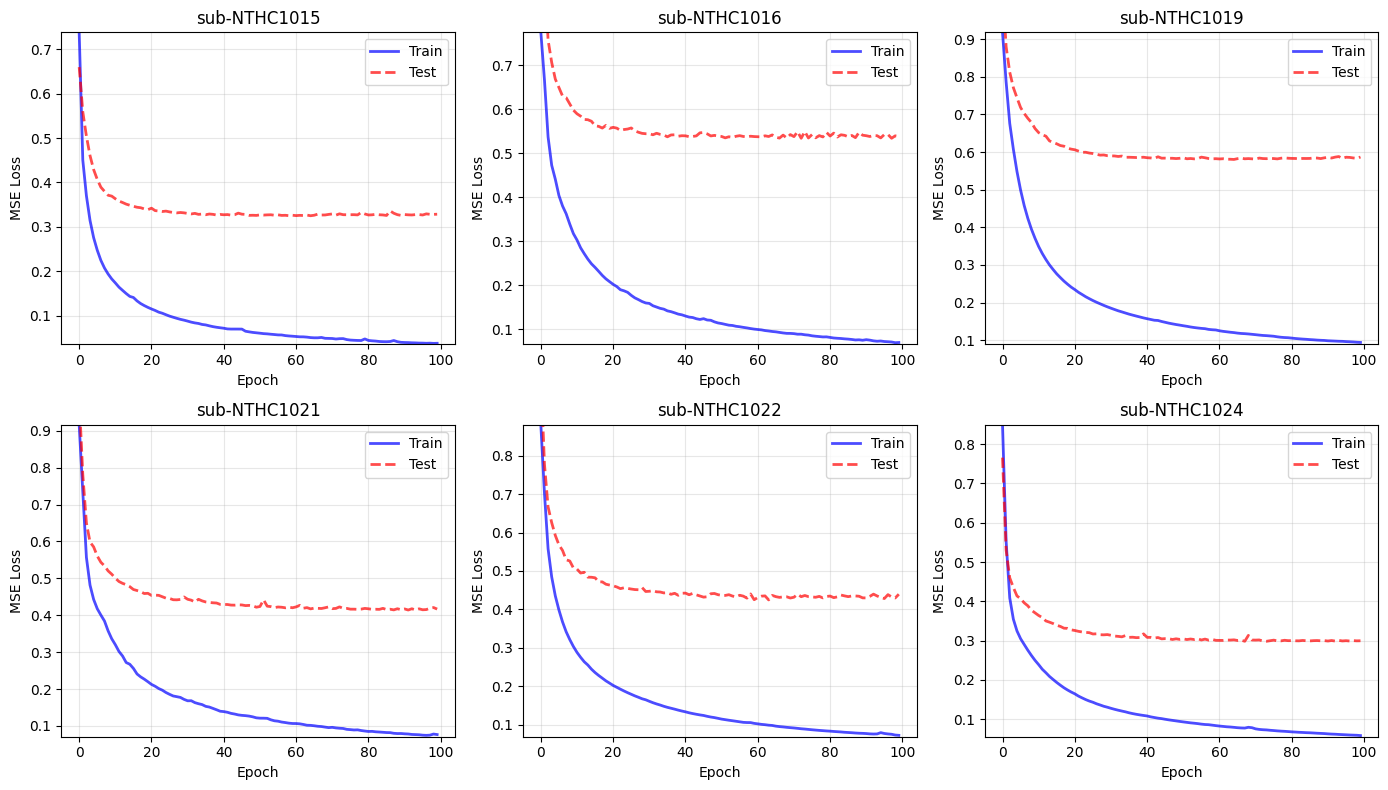

✓ Learning curves saved (train & test)


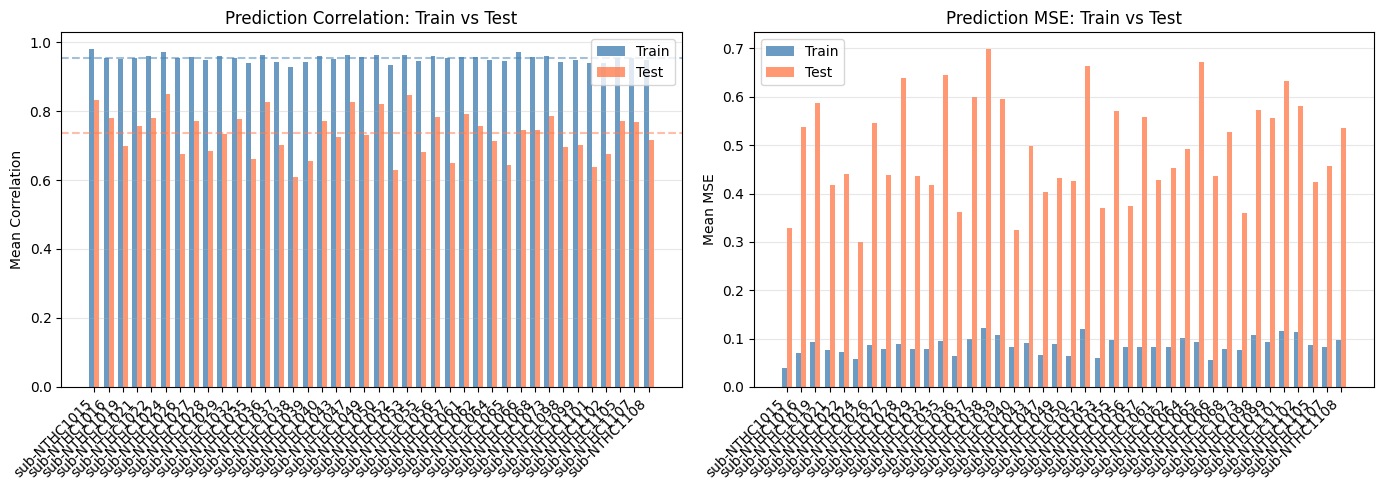

✓ Evaluation metrics saved (train & test)

Generating example prediction plot (test data)...


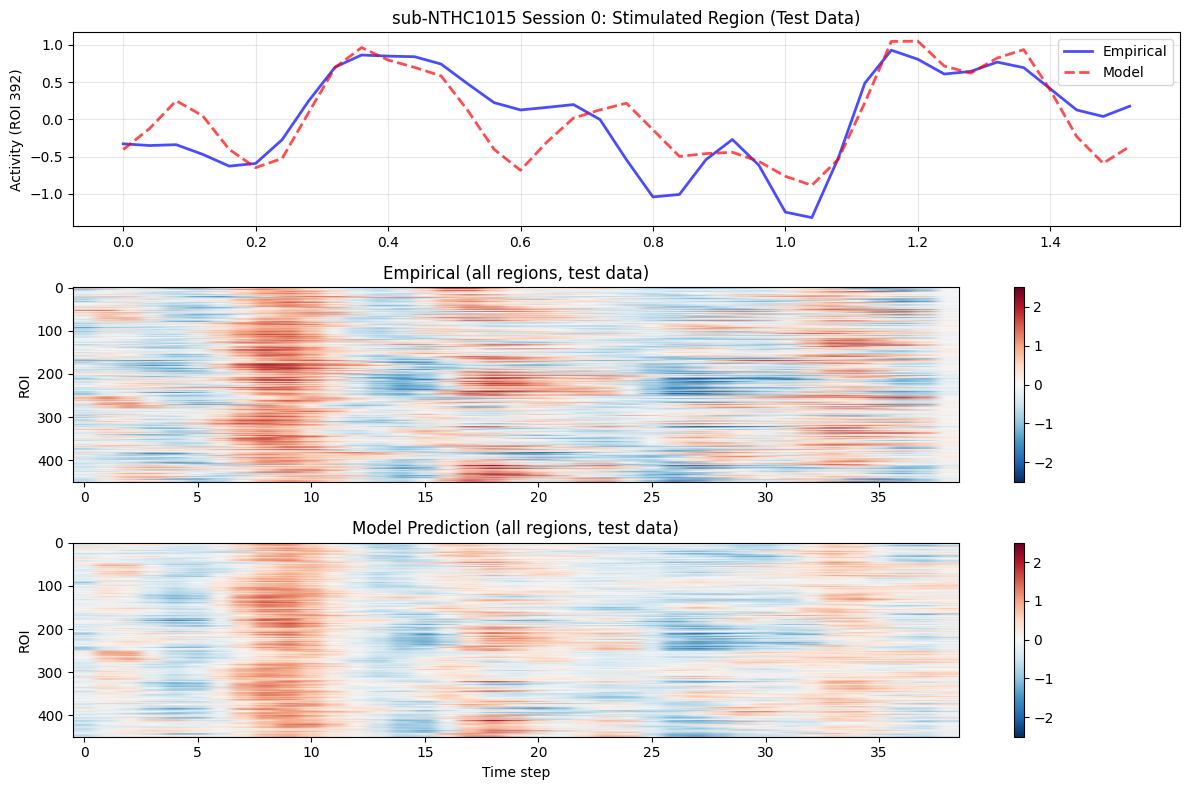

✓ Example prediction plot saved for sub-NTHC1015 (test data)

VISUALIZATION COMPLETE


In [10]:
# --- Visualization: Learning curves (train & test), metrics, and example predictions ---

import matplotlib.pyplot as plt
from scipy import stats as sp_stats

print("Generating visualizations...")

# 1. Learning curves per subject (TRAIN AND TEST)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for idx, sub_id in enumerate(sorted(trained_models.keys())[:6]):
    ax = axes[idx]
    train_losses = training_results[sub_id]['train_loss']
    test_losses = training_results[sub_id]['test_loss']

    epochs = np.arange(len(train_losses))
    ax.plot(epochs, train_losses, 'b-', label='Train', linewidth=2, alpha=0.7)
    if test_losses:
        ax.plot(epochs, test_losses, 'r--', label='Test', linewidth=2, alpha=0.7)

    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title(f'{sub_id}')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_ylim([min(train_losses) * 0.95, max(train_losses[:10]) * 1.0])

if len(trained_models) < 6:
    for idx in range(len(trained_models), 6):
        axes[idx].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'learning_curves.png'), dpi=150)
plt.show()

print("✓ Learning curves saved (train & test)")

# 2. Mean correlation on TRAIN and TEST per subject
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

subjects = sorted(evaluation_results.keys())
train_corrs = [evaluation_results[s]['train']['avg_correlation'] for s in subjects]
test_corrs = [evaluation_results[s]['test']['avg_correlation'] for s in subjects]

x = np.arange(len(subjects))
width = 0.35

bars1 = ax1.bar(x - width/2, train_corrs, width, label='Train', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, test_corrs, width, label='Test', color='coral', alpha=0.8)

ax1.set_ylabel('Mean Correlation')
ax1.set_title('Prediction Correlation: Train vs Test')
ax1.set_xticks(x)
ax1.set_xticklabels(subjects, rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend()
ax1.axhline(np.mean(train_corrs), color='steelblue', linestyle='--', alpha=0.5, label=f'Train mean={np.mean(train_corrs):.3f}')
ax1.axhline(np.mean(test_corrs), color='coral', linestyle='--', alpha=0.5, label=f'Test mean={np.mean(test_corrs):.3f}')

# 3. Mean MSE on TRAIN and TEST per subject
train_mses = [evaluation_results[s]['train']['avg_mse'] for s in subjects]
test_mses = [evaluation_results[s]['test']['avg_mse'] for s in subjects]

bars3 = ax2.bar(x - width/2, train_mses, width, label='Train', color='steelblue', alpha=0.8)
bars4 = ax2.bar(x + width/2, test_mses, width, label='Test', color='coral', alpha=0.8)

ax2.set_ylabel('Mean MSE')
ax2.set_title('Prediction MSE: Train vs Test')
ax2.set_xticks(x)
ax2.set_xticklabels(subjects, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'evaluation_metrics.png'), dpi=150)
plt.show()

print("✓ Evaluation metrics saved (train & test)")

# 4. Example: Single subject, single session prediction (TEST DATA ONLY)
print("\nGenerating example prediction plot (test data)...")

example_sub = sorted(trained_models.keys())[0]
if example_sub in dataset_emp and 'task-stim' in dataset_emp[example_sub]:
    stim_sessions = dataset_emp[example_sub]['task-stim']
    example_sess = sorted(stim_sessions.keys())[0]

    sess_data = stim_sessions[example_sess]
    ts = sess_data.get('time series')
    target_vec = sess_data.get('target')
    stim_time_df = sess_data.get('stim time')  # Get stimulus timing

    if ts is not None and target_vec is not None:
        ts_orig = np.asarray(ts, dtype=np.float32)
        ts = ts_orig[remove_initial_trs:, :]
        ts_proc = preprocess_run(ts, tr=tr_stim, n_drop=0, low=low_hz, high=high_hz, order=2, zscore=True)
        target_vec = np.asarray(target_vec, dtype=np.float32).ravel()

        # Extract stimulus timing (same as in data preparation)
        stim_pulse = np.zeros(ts_proc.shape[0], dtype=np.float32)
        if stim_time_df is not None and len(stim_time_df) > 0:
            stim_onsets = stim_time_df['onset'].values
            raw_tr_indices = np.round(stim_onsets / tr_stim).astype(int)
            valid_raw_indices = raw_tr_indices[raw_tr_indices >= remove_initial_trs]
            preprocessed_indices = valid_raw_indices - remove_initial_trs
            valid_preprocessed_indices = preprocessed_indices[preprocessed_indices < ts_proc.shape[0]]
            stim_pulse[valid_preprocessed_indices] = 1.0

        # Split: use ONLY test portion
        n_train = int((1.0 - test_fraction) * ts_proc.shape[0])
        ts_test_only = ts_proc[n_train:]
        stim_test_only = stim_pulse[n_train:]

        # Get predictions on test data only
        T, N = ts_test_only.shape
        if T > using_steps:
            test_inputs = np.empty((T - using_steps, using_steps * N + N + 1), dtype=np.float32)
            for t in range(T - using_steps):
                brain_state = ts_test_only[t : t + using_steps].reshape(-1)
                test_inputs[t] = np.concatenate([brain_state, target_vec, [stim_test_only[t]]])
            test_targets = ts_test_only[using_steps:, :]

            model = trained_models[example_sub]
            model.eval()
            with torch.no_grad():
                X_test_tensor = torch.tensor(test_inputs, dtype=torch.float32, device=device)
                Y_pred_tensor = model(X_test_tensor)
                Y_pred = Y_pred_tensor.cpu().numpy()

            # Plot: Example region time series
            target_roi = np.argmax(target_vec)

            fig, axes = plt.subplots(3, 1, figsize=(12, 8))

            # Full time series (test data only)
            time_vec = np.arange(test_targets.shape[0]) * tr_stim / 60  # in minutes
            axes[0].plot(time_vec, test_targets[:, target_roi], 'b-', label='Empirical', alpha=0.7, linewidth=2)
            axes[0].plot(time_vec, Y_pred[:, target_roi], 'r--', label='Model', alpha=0.7, linewidth=2)
            axes[0].set_ylabel(f'Activity (ROI {target_roi})')
            axes[0].set_title(f'{example_sub} Session {example_sess}: Stimulated Region (Test Data)')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)

            # Heatmap: All regions (test data only)
            vmin, vmax = -2.5, 2.5
            im1 = axes[1].imshow(test_targets.T, aspect='auto', cmap='RdBu_r', vmin=vmin, vmax=vmax)
            axes[1].set_ylabel('ROI')
            axes[1].set_title('Empirical (all regions, test data)')
            plt.colorbar(im1, ax=axes[1])

            im2 = axes[2].imshow(Y_pred.T, aspect='auto', cmap='RdBu_r', vmin=vmin, vmax=vmax)
            axes[2].set_ylabel('ROI')
            axes[2].set_xlabel('Time step')
            axes[2].set_title('Model Prediction (all regions, test data)')
            plt.colorbar(im2, ax=axes[2])

            plt.tight_layout()
            plt.savefig(os.path.join(results_dir, f'{example_sub}_session{example_sess}_prediction.png'), dpi=150)
            plt.show()

            print(f"✓ Example prediction plot saved for {example_sub} (test data)")

print("\n" + "="*70)
print("VISUALIZATION COMPLETE")
print("="*70)


---

## Summary: Per-Subject Perturbation-Aware ANN Models

### Overview

This notebook implements a **new approach** to modeling TMS-fMRI brain dynamics:

✅ **Per-subject models** (not population-level)  
✅ **Uses TMS stimulation sessions** for training (not just rest)  
✅ **Stimulus-aware ANN**: Explicit target region input during training  
✅ **Empirical validation**: Compares predictions to real TMS-fMRI responses  

### Key Methodological Differences

| Aspect | Old Approach (Fit_TMS_fMRI_data.ipynb) | New Approach (This Notebook) |
|--------|----------------------------------------|------------------------------|
| **Model scope** | Population (all subjects) | Per-subject (individual) |
| **Training data** | Rest sessions only | Stimulation sessions |
| **Stimulus input** | Applied during inference | Included during training |
| **Input dimension** | $S \times N$ (brain state) | $(S \times N) + N$ (state + target) |
| **Target sessions** | Fixed stimulation region | Variable per session |

### Model Architecture

**Input:** $\mathbf{x}_t = [\mathbf{s}_t \parallel \mathbf{t}_t]$
- $\mathbf{s}_t \in \mathbb{R}^{S \times N}$: concatenated brain state (S past steps × N regions)
- $\mathbf{t}_t \in \mathbb{R}^N$: binary stimulus target vector (one-hot)

**Output:** $\mathbf{y}_t = f_\theta(\mathbf{x}_t) \in \mathbb{R}^N$ (next brain state)

**Architecture:** MLP with ReLU activations
- Layer 1: $(S \cdot N + N) \to 256$
- Layer 2: $256 \to 128$
- Layer 3: $128 \to N$

### Pipeline

1. **Section 1:** Setup and environment configuration
2. **Section 2:** Load dataset with inspection of stimulation sessions
3. **Section 3:** Extract per-subject stimulation sessions with per-session train/test splits
   - Preprocess: drop initial TRs, bandpass filter (0.008–0.08 Hz), z-score
   - Encode stimulus target as one-hot binary vector
   - Concatenate brain state + target into unified input
4. **Section 4:** Train one MLP model per subject
   - Input: (brain state | stimulus target)
   - Loss: MSE on next-step prediction
   - Hyperparameters: 100 epochs, batch_size=32, lr=2.5e-4
5. **Section 5:** Evaluate on held-out test data from each session
   - Metrics: MSE, per-timestep prediction correlation
   - Per-subject and per-session summaries
6. **Section 6:** Visualize
   - Learning curves per subject
   - Evaluation metrics (MSE, correlation distributions)
   - Example: single-subject, single-session time series prediction

### Data Preparation Details

**For each stimulation session:**
1. Extract raw fMRI time series (T, N)
2. Drop first 30 TRs
3. Bandpass filter [0.008, 0.08] Hz
4. Z-score per region
5. Split: last 30% as test, first 70% as train
6. Build sliding-window inputs with stimulus channel:
   $$\mathbf{x}_i = [\mathbf{s}_{t:t+S} \parallel \mathbf{t}]$$
   where $\mathbf{t}$ is the (450,) binary target vector for that session

**Aggregation:** Concatenate all samples across all sessions for that subject → single training set

### Expected Outputs

- **trained_models_MLP_tms_fmri_persubject/**: Per-subject model weights (`.pt` files)
- **results_tms_fmri_persubject/**:
  - `training_results_persubject.json`: Summary of training loss per subject
  - `evaluation_results_persubject.json`: MSE and correlation metrics per subject
  - `learning_curves.png`: Plot of training loss over epochs
  - `evaluation_metrics.png`: Bar charts of prediction accuracy
  - `{sub_id}_session{idx}_prediction.png`: Example time series comparison

### Success Criteria

- Models converge (loss decreases monotonically)
- Mean correlation between predicted and empirical activity > 0
- Better per-subject MSE than population baseline
- Stimulus target information improves predictions

### Next Steps

1. **Run this notebook** to train per-subject models
2. **Compare results** with population model (Fit_TMS_fMRI_data.ipynb)
3. **Analyze**: Which subjects/targets show best agreement?
4. **Refinements**: Adjust architecture, hyperparameters, preprocessing based on results
5. **Downstream**: Use trained models for sensitivity analysis, generalization testing, etc.

---